In [45]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv('imageset.csv')
print(df.shape)

(1384, 7501)


(np.float64(-0.5), np.float64(99.5), np.float64(74.5), np.float64(-0.5))

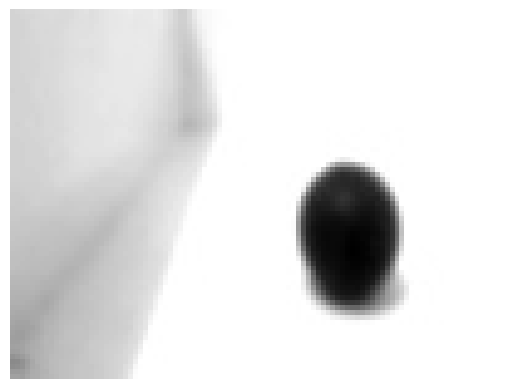

In [46]:
import numpy as np
some_image = df.loc[26,df.columns[:-1]] # type: ignore
some_image_np = some_image.to_numpy()

plt.imshow(np.reshape(some_image_np, (75,100)), cmap='gray')
plt.axis('off')

In [47]:
# problema binario
#X = df.loc[df['y'].isin([0, 1]),:]
#X = X.drop(columns={'y'})
#y = df.loc[df['y'].isin([0, 1]),'y']

#problema multiclasse
X = df.drop(columns={'y'})
y = df['y']


In [48]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40, stratify=y)

In [49]:
print(y_train.value_counts())
print(y_test.value_counts())

y
2    369
1    369
0    369
Name: count, dtype: int64
y
2    93
0    92
1    92
Name: count, dtype: int64


### aqui estou usando um SGD, mas pode testar e comparar outros classificadores à vontade, inclusive com pycaret (automl)

In [32]:
from sklearn.linear_model import SGDClassifier
model_sgd = SGDClassifier(random_state=42, penalty='l1') #se quiser reproduzir os resultados
model_sgd.fit(X_train, y_train)

,loss,'hinge'
,penalty,'l1'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [33]:
# vamos agora usar para detectar imagens com o número alvo
out = model_sgd.predict([some_image])
#print(out)

/home/joaovitor73/Documentos/Machine-Learning/reconhecimento-vitimas-obr/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


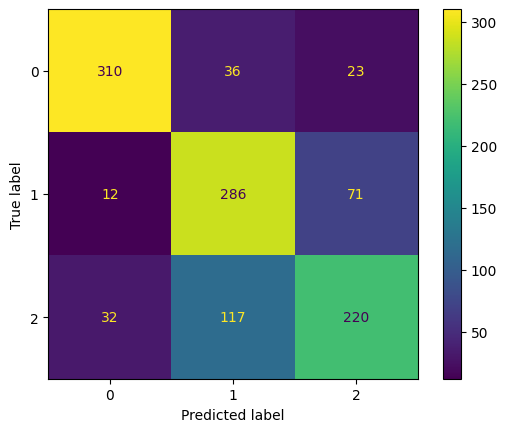

In [34]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(model_sgd, X_train, y_train, cv=5)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_true=y_train, y_pred=y_train_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=model_sgd.classes_)
disp.plot()

In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_train_pred, y_train))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       354
           1       0.78      0.65      0.71       439
           2       0.60      0.70      0.64       314

    accuracy                           0.74      1107
   macro avg       0.74      0.74      0.74      1107
weighted avg       0.75      0.74      0.74      1107



              precision    recall  f1-score   support

           0       0.87      0.93      0.90        86
           1       0.66      0.79      0.72        77
           2       0.84      0.68      0.75       114

    accuracy                           0.79       277
   macro avg       0.79      0.80      0.79       277
weighted avg       0.80      0.79      0.79       277



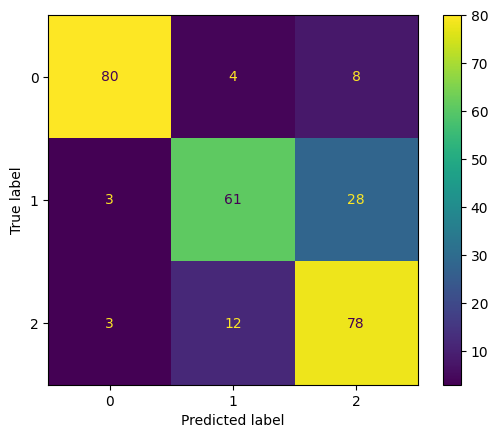

In [36]:
y_test_pred = model_sgd.predict(X_test)
cm = confusion_matrix(y_true=y_test, y_pred=y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=model_sgd.classes_)
disp.plot()

print(classification_report(y_test_pred, y_test))

In [14]:
import pickle
with open("victim_classifier_bin.pkl", "wb") as f:
    pickle.dump(model_sgd, f)

print("Modelo salvo")

Modelo salvo


#### Faria leitura do modelo para predições

In [15]:
with open('victim_classifier_bin.pkl', "rb") as f:
    model = pickle.load(f)

output = model.predict([some_image])
print(output)

[0]


c:\Users\josen\anaconda3\envs\tadsml\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


In [50]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import SGDClassifier

model_sgd = SGDClassifier(random_state=42)

# 3. Definir espaço de busca de hiperparâmetros
param_distributions = {
    "loss": ["hinge", "log_loss", "modified_huber", "squared_hinge", "perceptron"],
    "penalty": ["l2", "l1", "elasticnet"],
    "alpha": [1e-6, 1e-1],   # força da regularização
    "l1_ratio": [0, 1],         # só usado no elasticnet
    "max_iter": [1000, 2000, 3000],
    "learning_rate": ["optimal", "invscaling", "adaptive"],
    "eta0": [1e-4, 1e-1],    # taxa inicial
    "power_t": [0.1, 0.9],      # usado no invscaling
}

# 4. Configurar o RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=model_sgd,
    param_distributions=param_distributions,
    n_iter=50,              # número de combinações testadas
    cv=5,                   # cross-validation
    scoring="accuracy",
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# 5. Rodar a busca
random_search.fit(X_train, y_train)

# 6. Melhor combinação encontrada
print("Melhores hiperparâmetros:", random_search.best_params_)
print("Melhor score de validação cruzada:", random_search.best_score_)



Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END alpha=0.1, eta0=0.1, l1_ratio=1, learning_rate=adaptive, loss=hinge, max_iter=2000, penalty=l1, power_t=0.9; total time=  52.4s


/home/joaovitor73/Documentos/Machine-Learning/reconhecimento-vitimas-obr/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


[CV] END alpha=0.1, eta0=0.1, l1_ratio=1, learning_rate=adaptive, loss=hinge, max_iter=2000, penalty=l1, power_t=0.9; total time= 1.8min
[CV] END alpha=1e-06, eta0=0.1, l1_ratio=0, learning_rate=invscaling, loss=modified_huber, max_iter=1000, penalty=l1, power_t=0.1; total time=   4.3s
[CV] END alpha=1e-06, eta0=0.1, l1_ratio=0, learning_rate=invscaling, loss=modified_huber, max_iter=1000, penalty=l1, power_t=0.1; total time=   4.6s
[CV] END alpha=1e-06, eta0=0.1, l1_ratio=0, learning_rate=invscaling, loss=modified_huber, max_iter=1000, penalty=l1, power_t=0.1; total time=   4.2s
[CV] END alpha=1e-06, eta0=0.1, l1_ratio=0, learning_rate=invscaling, loss=modified_huber, max_iter=1000, penalty=l1, power_t=0.1; total time=   4.6s
[CV] END alpha=1e-06, eta0=0.1, l1_ratio=0, learning_rate=invscaling, loss=modified_huber, max_iter=1000, penalty=l1, power_t=0.1; total time=   6.9s
[CV] END alpha=0.1, eta0=0.1, l1_ratio=1, learning_rate=adaptive, loss=hinge, max_iter=2000, penalty=l1, power_t=

/home/joaovitor73/Documentos/Machine-Learning/reconhecimento-vitimas-obr/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


[CV] END alpha=0.1, eta0=0.1, l1_ratio=1, learning_rate=adaptive, loss=hinge, max_iter=2000, penalty=l1, power_t=0.9; total time= 3.2min


/home/joaovitor73/Documentos/Machine-Learning/reconhecimento-vitimas-obr/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


[CV] END alpha=0.1, eta0=0.1, l1_ratio=1, learning_rate=adaptive, loss=hinge, max_iter=2000, penalty=l1, power_t=0.9; total time= 3.3min
[CV] END alpha=0.1, eta0=0.1, l1_ratio=1, learning_rate=adaptive, loss=hinge, max_iter=1000, penalty=l1, power_t=0.9; total time=  54.1s


/home/joaovitor73/Documentos/Machine-Learning/reconhecimento-vitimas-obr/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


[CV] END alpha=0.1, eta0=0.1, l1_ratio=1, learning_rate=adaptive, loss=hinge, max_iter=1000, penalty=l1, power_t=0.9; total time= 1.2min


/home/joaovitor73/Documentos/Machine-Learning/reconhecimento-vitimas-obr/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


[CV] END alpha=0.1, eta0=0.1, l1_ratio=1, learning_rate=adaptive, loss=hinge, max_iter=1000, penalty=l1, power_t=0.9; total time= 2.2min
[CV] END alpha=0.1, eta0=0.0001, l1_ratio=0, learning_rate=optimal, loss=log_loss, max_iter=3000, penalty=l1, power_t=0.9; total time=  11.8s
[CV] END alpha=0.1, eta0=0.0001, l1_ratio=0, learning_rate=optimal, loss=log_loss, max_iter=3000, penalty=l1, power_t=0.9; total time=  14.3s
[CV] END alpha=0.1, eta0=0.0001, l1_ratio=0, learning_rate=optimal, loss=log_loss, max_iter=3000, penalty=l1, power_t=0.9; total time=   6.9s
[CV] END alpha=0.1, eta0=0.0001, l1_ratio=0, learning_rate=optimal, loss=log_loss, max_iter=3000, penalty=l1, power_t=0.9; total time=  16.8s
[CV] END alpha=0.1, eta0=0.0001, l1_ratio=0, learning_rate=optimal, loss=log_loss, max_iter=3000, penalty=l1, power_t=0.9; total time=   8.8s


/home/joaovitor73/Documentos/Machine-Learning/reconhecimento-vitimas-obr/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


[CV] END alpha=0.1, eta0=0.1, l1_ratio=1, learning_rate=adaptive, loss=hinge, max_iter=1000, penalty=l1, power_t=0.9; total time= 1.9min
[CV] END alpha=1e-06, eta0=0.1, l1_ratio=0, learning_rate=adaptive, loss=squared_hinge, max_iter=3000, penalty=l1, power_t=0.1; total time=  13.7s
[CV] END alpha=1e-06, eta0=0.1, l1_ratio=0, learning_rate=adaptive, loss=squared_hinge, max_iter=3000, penalty=l1, power_t=0.1; total time=  16.2s
[CV] END alpha=1e-06, eta0=0.1, l1_ratio=0, learning_rate=adaptive, loss=squared_hinge, max_iter=3000, penalty=l1, power_t=0.1; total time=  13.1s
[CV] END alpha=1e-06, eta0=0.1, l1_ratio=0, learning_rate=adaptive, loss=squared_hinge, max_iter=3000, penalty=l1, power_t=0.1; total time=  17.2s
[CV] END alpha=0.1, eta0=0.1, l1_ratio=0, learning_rate=invscaling, loss=squared_hinge, max_iter=3000, penalty=elasticnet, power_t=0.1; total time=   6.6s
[CV] END alpha=1e-06, eta0=0.1, l1_ratio=0, learning_rate=adaptive, loss=squared_hinge, max_iter=3000, penalty=l1, power

/home/joaovitor73/Documentos/Machine-Learning/reconhecimento-vitimas-obr/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


[CV] END alpha=0.1, eta0=0.1, l1_ratio=1, learning_rate=adaptive, loss=hinge, max_iter=1000, penalty=l1, power_t=0.9; total time= 1.5min
[CV] END alpha=0.1, eta0=0.1, l1_ratio=0, learning_rate=optimal, loss=modified_huber, max_iter=3000, penalty=elasticnet, power_t=0.1; total time=   8.3s
[CV] END alpha=0.1, eta0=0.1, l1_ratio=0, learning_rate=invscaling, loss=hinge, max_iter=2000, penalty=l2, power_t=0.9; total time=   7.8s
[CV] END alpha=0.1, eta0=0.1, l1_ratio=0, learning_rate=invscaling, loss=hinge, max_iter=2000, penalty=l2, power_t=0.9; total time=   8.8s
[CV] END alpha=0.1, eta0=0.1, l1_ratio=0, learning_rate=invscaling, loss=hinge, max_iter=2000, penalty=l2, power_t=0.9; total time=   3.8s
[CV] END alpha=0.1, eta0=0.1, l1_ratio=0, learning_rate=invscaling, loss=hinge, max_iter=2000, penalty=l2, power_t=0.9; total time=   3.7s
[CV] END alpha=0.1, eta0=0.1, l1_ratio=0, learning_rate=invscaling, loss=hinge, max_iter=2000, penalty=l2, power_t=0.9; total time=   3.4s
[CV] END alpha=

/home/joaovitor73/Documentos/Machine-Learning/reconhecimento-vitimas-obr/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


[CV] END alpha=0.1, eta0=0.1, l1_ratio=1, learning_rate=adaptive, loss=perceptron, max_iter=3000, penalty=l1, power_t=0.9; total time= 2.9min
[CV] END alpha=0.1, eta0=0.1, l1_ratio=1, learning_rate=adaptive, loss=perceptron, max_iter=3000, penalty=l1, power_t=0.9; total time= 2.2min
[CV] END alpha=1e-06, eta0=0.1, l1_ratio=0, learning_rate=invscaling, loss=modified_huber, max_iter=2000, penalty=l1, power_t=0.1; total time=   7.6s
[CV] END alpha=1e-06, eta0=0.1, l1_ratio=0, learning_rate=invscaling, loss=modified_huber, max_iter=2000, penalty=l1, power_t=0.1; total time=   4.5s
[CV] END alpha=1e-06, eta0=0.1, l1_ratio=0, learning_rate=invscaling, loss=modified_huber, max_iter=2000, penalty=l1, power_t=0.1; total time=   7.2s
[CV] END alpha=1e-06, eta0=0.1, l1_ratio=0, learning_rate=invscaling, loss=modified_huber, max_iter=2000, penalty=l1, power_t=0.1; total time=   5.3s
[CV] END alpha=0.1, eta0=0.1, l1_ratio=1, learning_rate=invscaling, loss=log_loss, max_iter=3000, penalty=l2, power_

/home/joaovitor73/Documentos/Machine-Learning/reconhecimento-vitimas-obr/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


[CV] END alpha=0.1, eta0=0.1, l1_ratio=1, learning_rate=adaptive, loss=perceptron, max_iter=3000, penalty=l1, power_t=0.9; total time= 5.1min
[CV] END alpha=0.1, eta0=0.1, l1_ratio=0, learning_rate=optimal, loss=log_loss, max_iter=1000, penalty=l1, power_t=0.9; total time=   9.7s


/home/joaovitor73/Documentos/Machine-Learning/reconhecimento-vitimas-obr/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


[CV] END alpha=0.1, eta0=0.1, l1_ratio=1, learning_rate=adaptive, loss=perceptron, max_iter=3000, penalty=l1, power_t=0.9; total time= 5.1min
[CV] END alpha=0.1, eta0=0.1, l1_ratio=0, learning_rate=optimal, loss=log_loss, max_iter=1000, penalty=l1, power_t=0.9; total time=   7.3s
[CV] END alpha=0.1, eta0=0.1, l1_ratio=0, learning_rate=optimal, loss=log_loss, max_iter=1000, penalty=l1, power_t=0.9; total time=  12.3s
[CV] END alpha=0.1, eta0=0.1, l1_ratio=0, learning_rate=optimal, loss=log_loss, max_iter=1000, penalty=l1, power_t=0.9; total time=   7.0s
[CV] END alpha=0.1, eta0=0.1, l1_ratio=0, learning_rate=optimal, loss=log_loss, max_iter=1000, penalty=l1, power_t=0.9; total time=  12.6s


/home/joaovitor73/Documentos/Machine-Learning/reconhecimento-vitimas-obr/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


[CV] END alpha=0.1, eta0=0.1, l1_ratio=0, learning_rate=adaptive, loss=modified_huber, max_iter=2000, penalty=l1, power_t=0.9; total time= 2.7min


/home/joaovitor73/Documentos/Machine-Learning/reconhecimento-vitimas-obr/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


[CV] END alpha=0.1, eta0=0.1, l1_ratio=0, learning_rate=adaptive, loss=modified_huber, max_iter=2000, penalty=l1, power_t=0.9; total time= 4.6min


/home/joaovitor73/Documentos/Machine-Learning/reconhecimento-vitimas-obr/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


[CV] END alpha=0.1, eta0=0.1, l1_ratio=0, learning_rate=adaptive, loss=modified_huber, max_iter=2000, penalty=l1, power_t=0.9; total time= 4.7min
[CV] END alpha=0.1, eta0=0.1, l1_ratio=1, learning_rate=optimal, loss=modified_huber, max_iter=3000, penalty=l1, power_t=0.1; total time=   9.5s
[CV] END alpha=0.1, eta0=0.1, l1_ratio=1, learning_rate=optimal, loss=modified_huber, max_iter=3000, penalty=l1, power_t=0.1; total time=  14.9s
[CV] END alpha=0.1, eta0=0.1, l1_ratio=1, learning_rate=optimal, loss=modified_huber, max_iter=3000, penalty=l1, power_t=0.1; total time=  13.3s
[CV] END alpha=0.1, eta0=0.1, l1_ratio=1, learning_rate=optimal, loss=modified_huber, max_iter=3000, penalty=l1, power_t=0.1; total time=   9.1s
[CV] END alpha=0.1, eta0=0.1, l1_ratio=1, learning_rate=optimal, loss=modified_huber, max_iter=3000, penalty=l1, power_t=0.1; total time=   6.6s
[CV] END alpha=1e-06, eta0=0.1, l1_ratio=0, learning_rate=optimal, loss=perceptron, max_iter=2000, penalty=l1, power_t=0.9; total

/home/joaovitor73/Documentos/Machine-Learning/reconhecimento-vitimas-obr/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


[CV] END alpha=0.1, eta0=0.1, l1_ratio=0, learning_rate=adaptive, loss=modified_huber, max_iter=2000, penalty=l1, power_t=0.9; total time= 5.2min
[CV] END alpha=1e-06, eta0=0.1, l1_ratio=0, learning_rate=optimal, loss=perceptron, max_iter=2000, penalty=l1, power_t=0.9; total time=   7.4s
[CV] END alpha=1e-06, eta0=0.1, l1_ratio=0, learning_rate=optimal, loss=perceptron, max_iter=2000, penalty=l1, power_t=0.9; total time=   5.8s
[CV] END alpha=0.1, eta0=0.0001, l1_ratio=0, learning_rate=invscaling, loss=log_loss, max_iter=3000, penalty=elasticnet, power_t=0.1; total time=   4.5s
[CV] END alpha=1e-06, eta0=0.1, l1_ratio=0, learning_rate=optimal, loss=perceptron, max_iter=2000, penalty=l1, power_t=0.9; total time=   9.3s
[CV] END alpha=0.1, eta0=0.0001, l1_ratio=0, learning_rate=invscaling, loss=log_loss, max_iter=3000, penalty=elasticnet, power_t=0.1; total time=   5.4s
[CV] END alpha=0.1, eta0=0.0001, l1_ratio=0, learning_rate=invscaling, loss=log_loss, max_iter=3000, penalty=elasticnet

/home/joaovitor73/Documentos/Machine-Learning/reconhecimento-vitimas-obr/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


[CV] END alpha=0.1, eta0=0.1, l1_ratio=0, learning_rate=adaptive, loss=modified_huber, max_iter=2000, penalty=l1, power_t=0.9; total time= 3.4min
[CV] END alpha=1e-06, eta0=0.0001, l1_ratio=1, learning_rate=optimal, loss=perceptron, max_iter=2000, penalty=l1, power_t=0.1; total time=   9.5s
[CV] END alpha=1e-06, eta0=0.0001, l1_ratio=1, learning_rate=optimal, loss=perceptron, max_iter=2000, penalty=l1, power_t=0.1; total time=   7.7s
[CV] END alpha=0.1, eta0=0.0001, l1_ratio=1, learning_rate=adaptive, loss=squared_hinge, max_iter=1000, penalty=l1, power_t=0.1; total time=   9.9s
[CV] END alpha=0.1, eta0=0.0001, l1_ratio=1, learning_rate=adaptive, loss=squared_hinge, max_iter=1000, penalty=l1, power_t=0.1; total time=   8.1s
[CV] END alpha=1e-06, eta0=0.0001, l1_ratio=1, learning_rate=optimal, loss=perceptron, max_iter=2000, penalty=l1, power_t=0.1; total time=  11.7s
[CV] END alpha=0.1, eta0=0.0001, l1_ratio=1, learning_rate=adaptive, loss=squared_hinge, max_iter=1000, penalty=l1, powe

/home/joaovitor73/Documentos/Machine-Learning/reconhecimento-vitimas-obr/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


[CV] END alpha=1e-06, eta0=0.1, l1_ratio=1, learning_rate=adaptive, loss=hinge, max_iter=2000, penalty=elasticnet, power_t=0.1; total time= 2.5min
[CV] END alpha=1e-06, eta0=0.0001, l1_ratio=0, learning_rate=adaptive, loss=squared_hinge, max_iter=3000, penalty=elasticnet, power_t=0.9; total time=   8.4s
[CV] END alpha=1e-06, eta0=0.0001, l1_ratio=0, learning_rate=adaptive, loss=squared_hinge, max_iter=3000, penalty=elasticnet, power_t=0.9; total time=   9.5s
[CV] END alpha=1e-06, eta0=0.0001, l1_ratio=0, learning_rate=adaptive, loss=squared_hinge, max_iter=3000, penalty=elasticnet, power_t=0.9; total time=  10.2s
[CV] END alpha=1e-06, eta0=0.0001, l1_ratio=0, learning_rate=adaptive, loss=squared_hinge, max_iter=3000, penalty=elasticnet, power_t=0.9; total time=   7.8s


/home/joaovitor73/Documentos/Machine-Learning/reconhecimento-vitimas-obr/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


[CV] END alpha=1e-06, eta0=0.1, l1_ratio=1, learning_rate=adaptive, loss=hinge, max_iter=2000, penalty=elasticnet, power_t=0.1; total time= 2.9min
[CV] END alpha=0.1, eta0=0.0001, l1_ratio=1, learning_rate=optimal, loss=squared_hinge, max_iter=3000, penalty=elasticnet, power_t=0.1; total time=   9.5s
[CV] END alpha=0.1, eta0=0.0001, l1_ratio=1, learning_rate=optimal, loss=squared_hinge, max_iter=3000, penalty=elasticnet, power_t=0.1; total time=  14.2s
[CV] END alpha=0.1, eta0=0.0001, l1_ratio=1, learning_rate=optimal, loss=squared_hinge, max_iter=3000, penalty=elasticnet, power_t=0.1; total time=   8.7s
[CV] END alpha=0.1, eta0=0.0001, l1_ratio=1, learning_rate=optimal, loss=squared_hinge, max_iter=3000, penalty=elasticnet, power_t=0.1; total time=   7.5s
[CV] END alpha=0.1, eta0=0.0001, l1_ratio=1, learning_rate=optimal, loss=squared_hinge, max_iter=3000, penalty=elasticnet, power_t=0.1; total time=   6.9s
[CV] END alpha=1e-06, eta0=0.1, l1_ratio=1, learning_rate=invscaling, loss=squ

/home/joaovitor73/Documentos/Machine-Learning/reconhecimento-vitimas-obr/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


[CV] END alpha=0.1, eta0=0.1, l1_ratio=0, learning_rate=invscaling, loss=modified_huber, max_iter=1000, penalty=l2, power_t=0.9; total time=   5.1s
[CV] END alpha=0.1, eta0=0.1, l1_ratio=0, learning_rate=invscaling, loss=modified_huber, max_iter=1000, penalty=l2, power_t=0.9; total time=   3.8s
[CV] END alpha=0.1, eta0=0.1, l1_ratio=0, learning_rate=invscaling, loss=modified_huber, max_iter=1000, penalty=l2, power_t=0.9; total time=   5.8s
[CV] END alpha=0.1, eta0=0.1, l1_ratio=0, learning_rate=invscaling, loss=modified_huber, max_iter=1000, penalty=l2, power_t=0.9; total time=   4.4s
[CV] END alpha=0.1, eta0=0.1, l1_ratio=0, learning_rate=invscaling, loss=modified_huber, max_iter=1000, penalty=l2, power_t=0.9; total time=   2.9s
[CV] END alpha=0.1, eta0=0.1, l1_ratio=0, learning_rate=optimal, loss=modified_huber, max_iter=2000, penalty=elasticnet, power_t=0.9; total time=   7.5s
[CV] END alpha=0.1, eta0=0.1, l1_ratio=0, learning_rate=optimal, loss=modified_huber, max_iter=2000, penalt

In [51]:
from sklearn.metrics import classification_report
# 7. Avaliar no conjunto de teste
y_pred = random_search.best_estimator_.predict(X_test)
print("\nRelatório de classificação no teste:")
print(classification_report(y_test, y_pred))


Relatório de classificação no teste:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        92
           1       0.75      0.74      0.74        92
           2       0.73      0.74      0.74        93

    accuracy                           0.80       277
   macro avg       0.80      0.80      0.80       277
weighted avg       0.80      0.80      0.80       277



In [52]:
import pickle
with open("victim_classifier_100_75.pkl", "wb") as f:
    pickle.dump(random_search.best_estimator_, f)

print("Modelo otimizado salvo")

Modelo otimizado salvo
